# 13 - Overlay: theme conviction vs ETF price (AUTO, weekly)

Auto-picks the highest-sentiment themes and overlays each theme's conviction_z
against its ETF's price. `FREQ='W'` averages conviction weekly for a smoother
read.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2019-01-01 -> 2020-01-01


In [2]:
from src.themes import THEME_ETFS
HOW_MANY = 6
FREQ = 'W'        # 'W' weekly, 'D' daily, 'M' monthly
MIN_POSTS = 30    # ignore barely-discussed themes when ranking sentiment
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)

auto themes (highest sentiment): ['small_caps', 'biotech_pharma', 'meme_stocks', 'shipping_logistics', 'cannabis', 'cloud_saas']


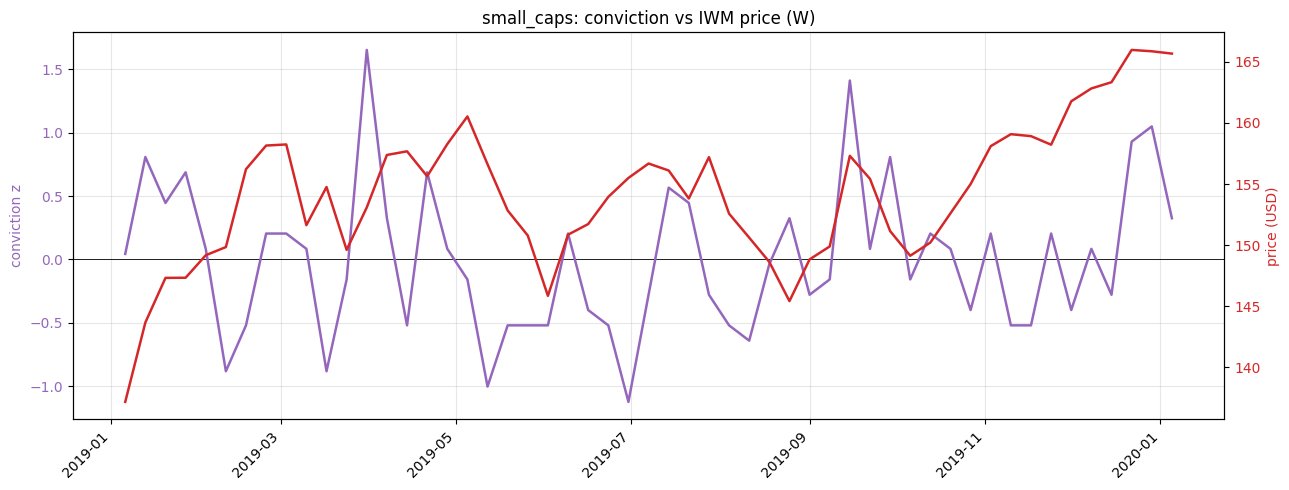

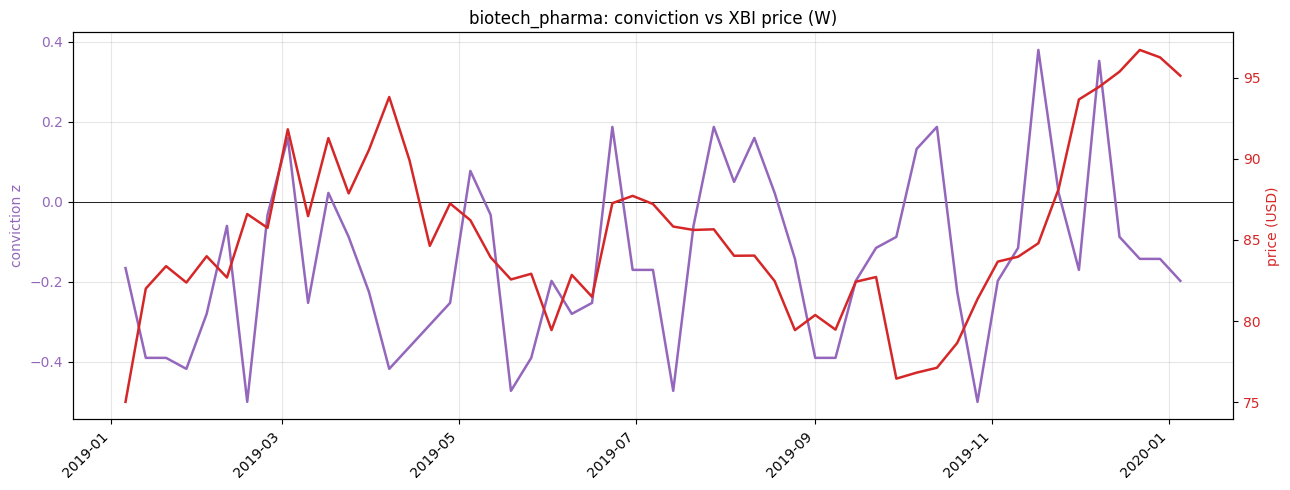

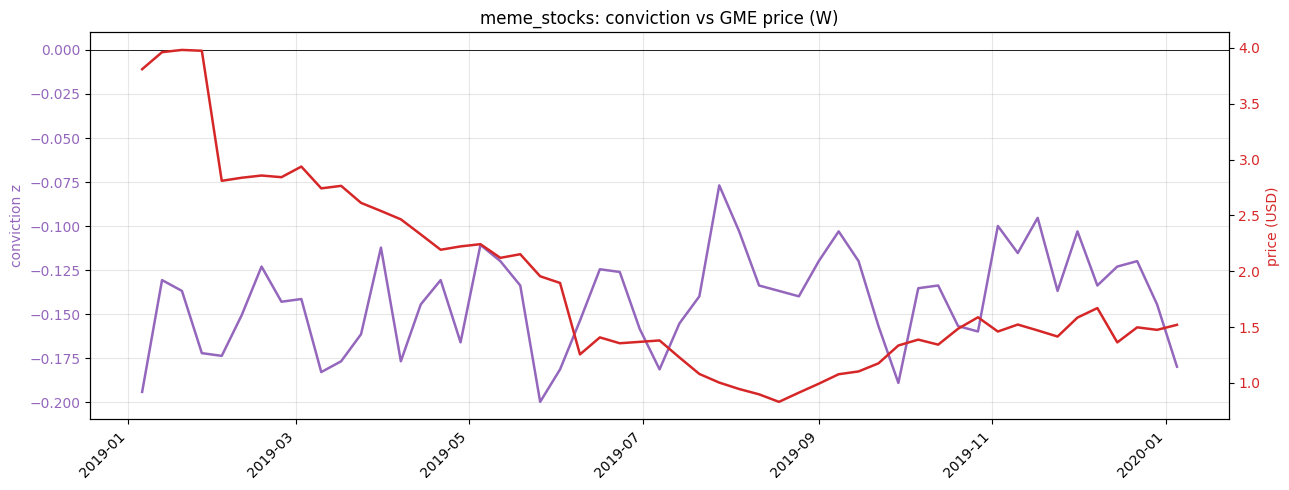

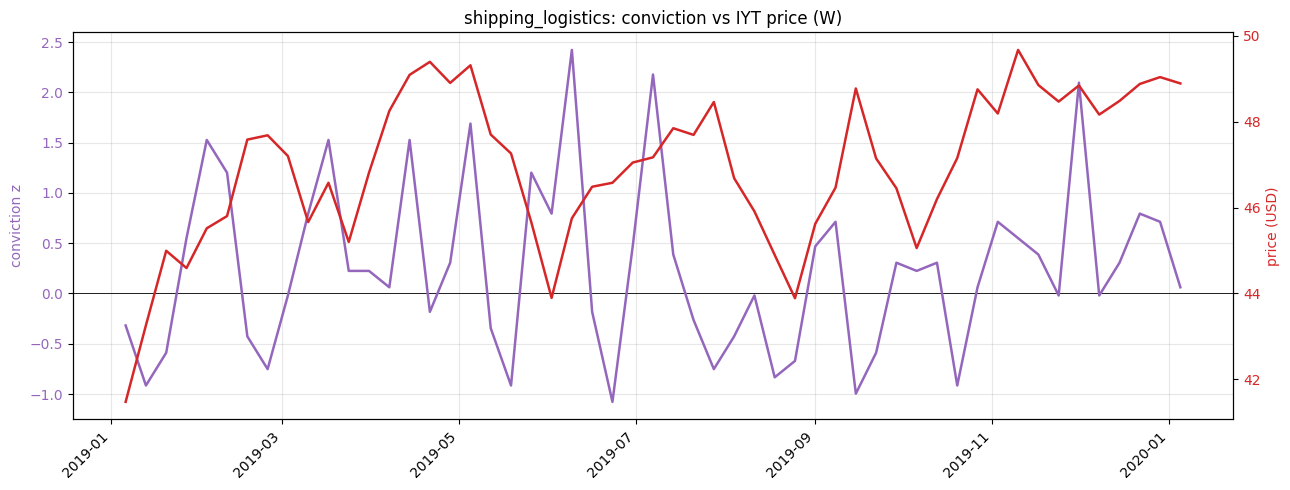

note cannabis - MSOS has no price data at all in prices.parquet - re-run pull_bloomberg_prices.py


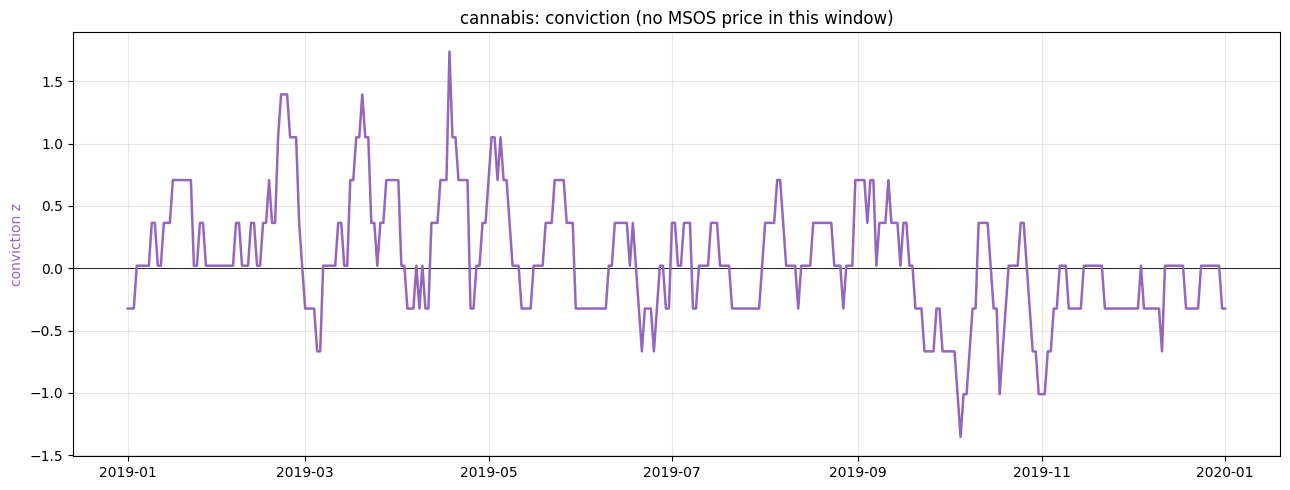

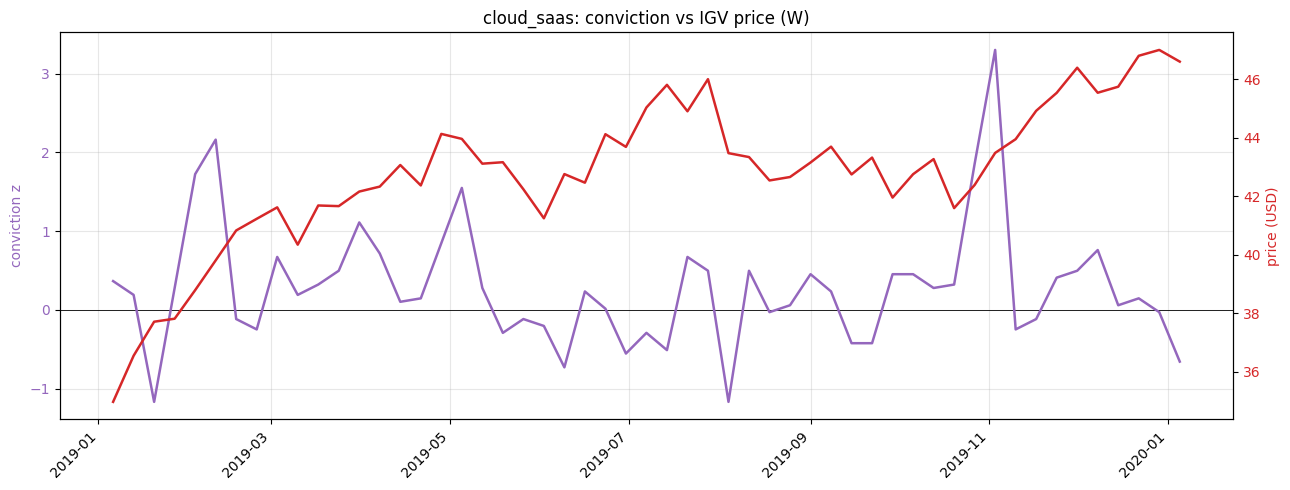

In [3]:
tsent = pd.read_parquet(os.path.join(P, 'daily_theme_sentiment.parquet'))
tsent['date'] = pd.to_datetime(tsent['date']); tsent = clip_dates(tsent, 'date')
if tsent.empty:
    print('!' * 72)
    print(f'NO AGGREGATE DATA in this window ({START_DATE} -> {END_DATE or "today"}).')
    print("Fix: run  python update_data.py --full  once (builds the aggregates")
    print('over ALL history); see the WINDOW CHECK in the run log for detail.')
    print('!' * 72)
posts = tsent.groupby('theme')['n_posts'].sum(); mood = tsent.groupby('theme')['net_bullish'].mean()
themes = mood[posts >= MIN_POSTS].sort_values(ascending=False).head(HOW_MANY).index.tolist()
print('auto themes (highest sentiment):', themes)
conv = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv['date'] = pd.to_datetime(conv['date'])
if PLOT_LAST_DAYS:                       # zoom: only the most recent stretch
    WIN_LO = max(WIN_LO, conv['date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
prices = load_prices()

for theme in themes:
    etf = THEME_ETFS.get(theme)
    if etf is None: print('skip', theme, '- no ETF'); continue
    c = clip_series(conv[conv['theme'] == theme].sort_values('date').set_index('date')['conviction_z'])
    px = price_series(prices, etf)
    # Young ETFs have no data early in the window (IBIT starts Jan-2024,
    # MAGS Apr-2023...). We do NOT substitute another instrument - we plot
    # whatever price history exists and mark where it begins.
    all_px = prices[prices['symbol'] == etf]
    price_starts = all_px['date'].min() if len(all_px) else None
    if px.empty:
        if price_starts is None:
            print('note', theme, f'- {etf} has no price data at all in prices.parquet '
                  '- re-run pull_bloomberg_prices.py')
        else:
            print('note', theme, f'- {etf} price data only starts {price_starts.date()} '
                  '(after this window) - plotting conviction alone')
        fig, ax1 = plt.subplots(figsize=(13, 5))
        ax1.axhline(0, color='black', linewidth=0.6)
        ax1.plot(c.index, c.values, color='tab:purple', linewidth=1.8)
        ax1.set_ylabel('conviction z', color='tab:purple')
        note = f'no {etf} price in this window' + (f' ({etf} starts {price_starts.date()})' if price_starts is not None else '')
        ax1.set_title(f'{theme}: conviction (' + note + ')')
        ax1.grid(True, alpha=0.3); fig.tight_layout(); plt.show()
        continue
    price_gap = price_starts is not None and (px.index.min() - WIN_LO).days > 7
    if price_gap:
        print('note', theme, f'- {etf} price data only starts {px.index.min().date()}')
    if FREQ != 'D':
        c = c.resample(FREQ).mean(); px = px.resample(FREQ).last()
    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.axhline(0, color='black', linewidth=0.6)
    ax1.plot(c.index, c.values, color='tab:purple', linewidth=1.8, label='conviction_z')
    ax1.set_ylabel('conviction z', color='tab:purple'); ax1.tick_params(axis='y', labelcolor='tab:purple')
    ax2 = ax1.twinx(); ax2.plot(px.index, px.values, color='tab:red', linewidth=1.8, label='price')
    ax2.set_ylabel('price (USD)', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
    if price_gap:
        ax1.axvline(px.index.min(), color='gray', linestyle='--', linewidth=1)
        ax1.annotate(f'{etf} price data starts', (px.index.min(), ax1.get_ylim()[1]),
                     fontsize=8, ha='left', va='top', color='gray')
    ax1.set_title(f'{theme}: conviction vs {etf} price ({FREQ})'); ax1.grid(True, alpha=0.3)
    set_date_ticks(ax1, X_TICKS)
    fig.tight_layout(); plt.show()